# 📘 S8_P2 (corrigé) — Clustering Iris : KMeans puis DBSCAN

## 🎯 Nouveau paradigme : l'apprentissage NON SUPERVISÉ

Jusqu'ici (S1→S7), tu faisais de l'apprentissage **supervisé** : on avait la « bonne réponse » (`y`) et le modèle apprenait à la reproduire.

Ici, changement de monde : le **clustering**. On donne au modèle des données **SANS étiquettes** et il doit **découvrir tout seul des groupes** (clusters) de points qui se ressemblent. Personne ne lui dit combien de groupes ni lesquels.

**Exemples réels :** segmenter des clients par comportement, regrouper des articles similaires, détecter des anomalies…

## 🗺️ Ce notebook
1. Standardiser + PCA
2. **KMeans** + coude/silhouette (rappel de S8_P1)
3. **DBSCAN** : le clustering par densité

---
Imports : numpy, pandas, le dataset **Iris** (fleurs), **PCA** (réduction de dimension) et Plotly.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import plotly.express as px

## 📖 Le dataset Iris

Le dataset le plus célèbre du ML : **150 fleurs d'iris**, décrites par 4 mesures (longueur/largeur des pétales et sépales), réparties en **3 espèces** (setosa, versicolor, virginica).

⚠️ **Important pour le clustering :** on a bien les vraies espèces (`iris.target`), mais on ne les donne PAS au modèle ! On s'en servira seulement **à la fin** pour VÉRIFIER si les groupes découverts correspondent aux vraies espèces.

In [17]:
 iris = load_iris()

In [20]:
X = iris.data
y = iris.target

In [21]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

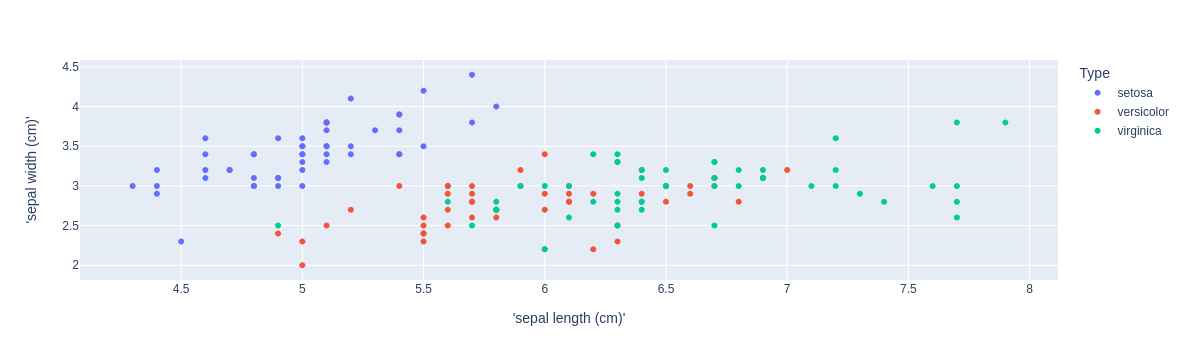

In [22]:
df_plot = pd.DataFrame({"'sepal length (cm)'": X[:,0], " 'sepal width (cm)'":X[:,1], "Type": iris.target_names[y]})
px.scatter(df_plot, x = "'sepal length (cm)'", y= " 'sepal width (cm)'", color="Type")

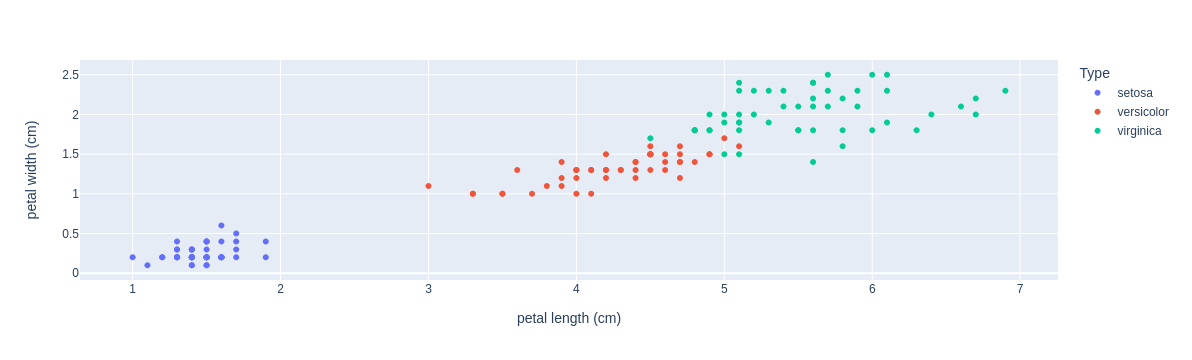

In [23]:
df_plot = pd.DataFrame({'petal length (cm)': X[:,2], 'petal width (cm)':X[:,3], "Type": iris.target_names[y]})
px.scatter(df_plot, x = 'petal length (cm)', y= 'petal width (cm)', color="Type")

## 🧠 THÉORIE — La standardisation (`StandardScaler`)

Le clustering repose sur des **distances** entre points. Or si une variable a de grandes valeurs (ex : longueur en cm) et une autre de petites (ex : largeur), la grande écrase la petite dans le calcul de distance — comme le piège du KNN (S3) !

`StandardScaler` **recentre chaque colonne** sur une moyenne de 0 et un écart-type de 1 :
$$x_{standardisé} = \frac{x - \text{moyenne}}{\text{écart-type}}$$

Ainsi toutes les variables pèsent **équitablement** dans les distances. C'est une étape quasi obligatoire avant KMeans et DBSCAN.

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X) 

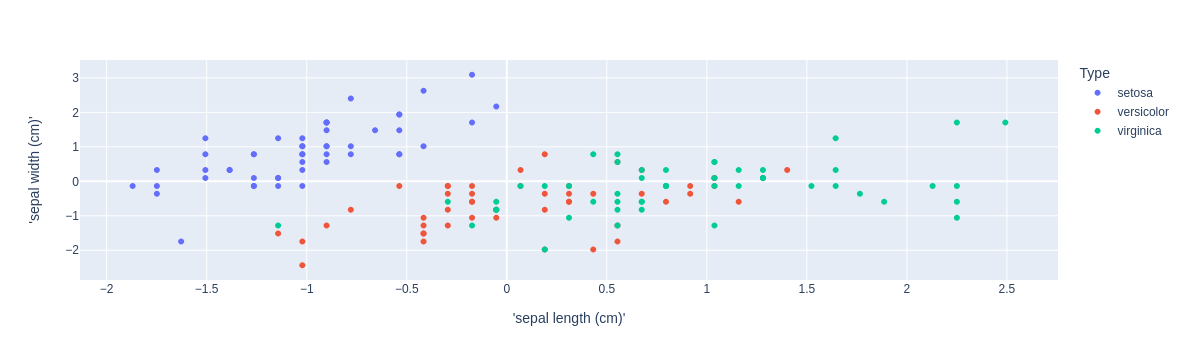

In [25]:
df_plot = pd.DataFrame({"'sepal length (cm)'": X[:,0], " 'sepal width (cm)'":X[:,1], "Type": iris.target_names[y]})
px.scatter(df_plot, x = "'sepal length (cm)'", y= " 'sepal width (cm)'", color="Type")

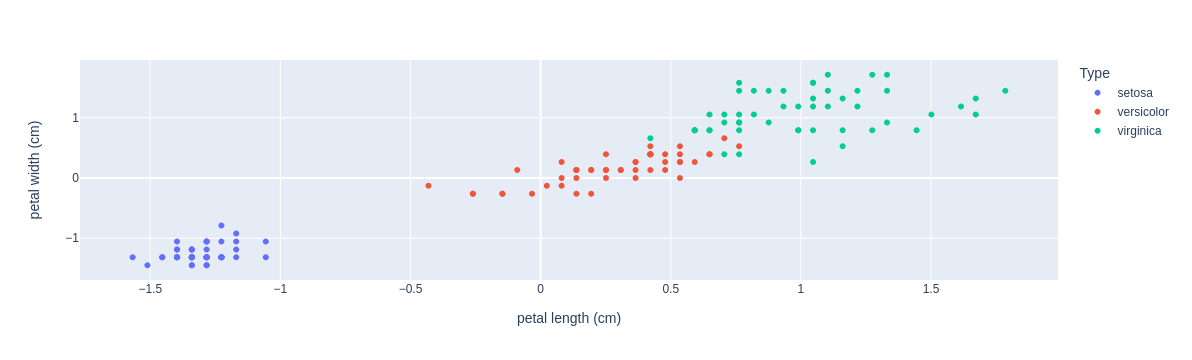

In [26]:
df_plot = pd.DataFrame({'petal length (cm)': X[:,2], 'petal width (cm)':X[:,3], "Type": iris.target_names[y]})
px.scatter(df_plot, x = 'petal length (cm)', y= 'petal width (cm)', color="Type")

In [27]:
y = iris.target

In [28]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## 🧠 THÉORIE — La PCA (Analyse en Composantes Principales)

Iris a **4 dimensions** (4 mesures) — impossible à dessiner sur un graphique 2D ! La **PCA** (*Principal Component Analysis*) résout ça : elle **compresse** les 4 dimensions en 2 (`n_components=2`), en gardant le **maximum d'information** (la variance).

**L'intuition :** la PCA trouve les 2 « axes » (PC1, PC2) le long desquels les points s'étalent le plus, puis projette dessus. On perd un peu d'info, mais on peut enfin VOIR les données en 2D.

`x_pca = pca.fit_transform(X)` → chaque fleur a maintenant 2 coordonnées (PC1, PC2) au lieu de 4. C'est un outil de **visualisation** et de réduction de dimension, pas un modèle de prédiction.

In [29]:
pca = PCA(n_components=2, random_state=32)
X_pca = pca.fit_transform(X)

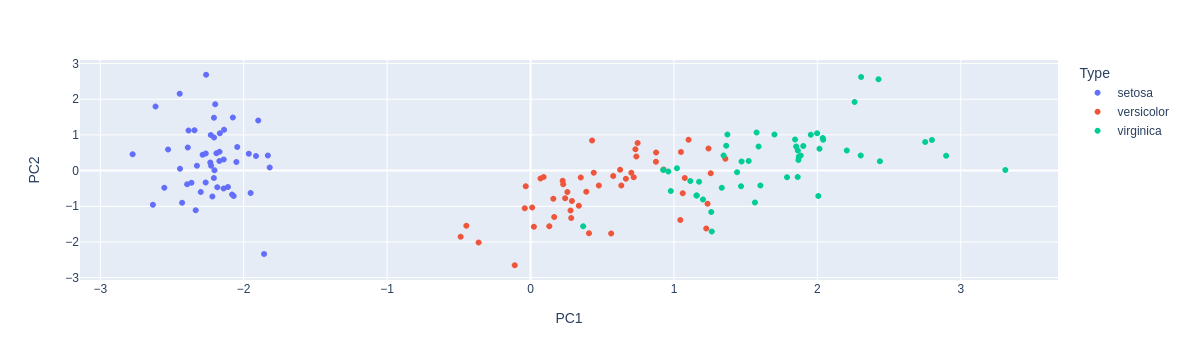

In [30]:
df_plot = pd.DataFrame({"PC1": X_pca[:,0], "PC2":X_pca[:,1], "Type": iris.target_names[y]})
px.scatter(df_plot, x = "PC1", y= "PC2", color="Type")

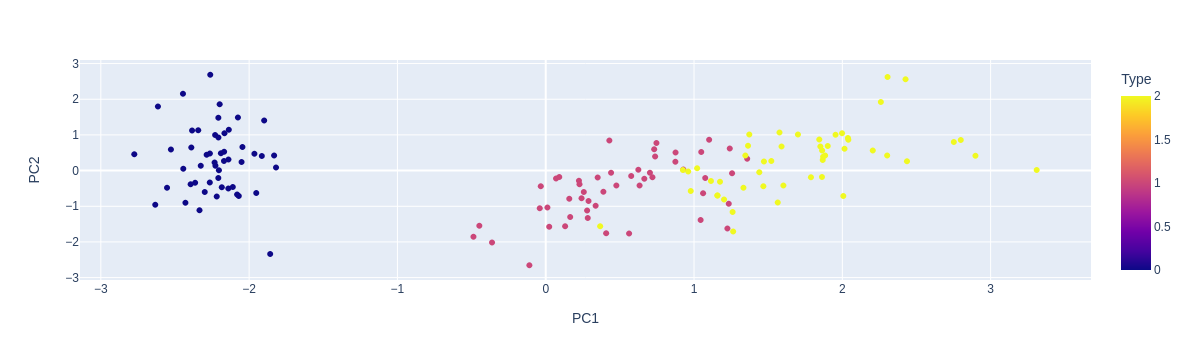

In [31]:
df_plot = pd.DataFrame({"PC1": X_pca[:,0], "PC2":X_pca[:,1], "Type": y})
px.scatter(df_plot, x = "PC1", y= "PC2", color="Type")

# K-MEANS

## 🧠 THÉORIE — KMeans : le clustering par centres

L'algorithme le plus classique. On lui donne **le nombre de clusters `k`** à trouver, et il procède ainsi :
1. Place k **centres** (centroïdes) au hasard,
2. Assigne chaque point au centre le plus proche,
3. Déplace chaque centre au milieu de ses points,
4. Répète 2-3 jusqu'à stabilité.

`kmeans.fit_predict(X)` renvoie le **numéro de cluster** (0, 1, 2…) de chaque point.

**⚠️ Deux limites à connaître :**
- Il faut **choisir k à l'avance** (d'où la « méthode du coude » et la silhouette, plus loin).
- KMeans ne fait que des clusters **ronds/sphériques** — il échoue sur des formes allongées ou entrelacées (tu le verras sur le dataset « moons »).

*(Cette partie KMeans reprend S8_P1 — voir ce notebook pour le détail.)*

In [32]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=32, n_init="auto")
clusters = kmeans.fit_predict(X_pca)

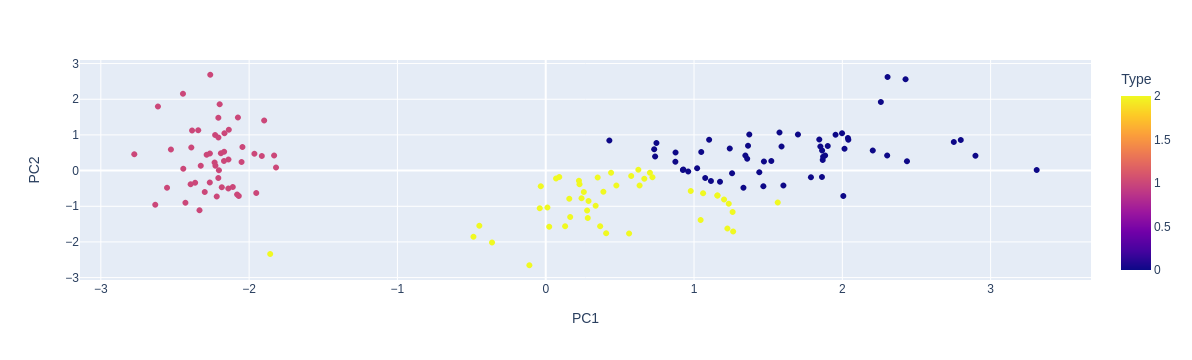

In [33]:
df_plot = pd.DataFrame({"PC1": X_pca[:,0], "PC2":X_pca[:,1], "Type": clusters})
px.scatter(df_plot, x = "PC1", y= "PC2", color="Type")

In [34]:
kmeans.cluster_centers_

array([[ 1.63395833,  0.48398172],
       [-2.23223542,  0.34252628],
       [ 0.42417016, -0.94353874]])

In [35]:
kmeans.inertia_

116.0177431670424

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

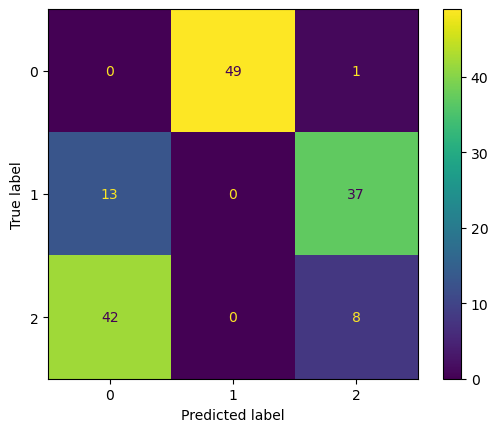

In [37]:
ConfusionMatrixDisplay.from_predictions(y, clusters)

In [38]:
cm = confusion_matrix(y, clusters)

In [39]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import silhouette_score

## 🧠 THÉORIE — La méthode du COUDE (choisir k)

Comment choisir le bon nombre de clusters ? On trace l'**inertie (SSE) en fonction de k** :
- k trop petit → clusters énormes, inertie élevée,
- k trop grand → inertie faible mais clusters inutilement fragmentés.

**🔍 Le « coude » :** l'inertie chute fort au début puis se stabilise. Le point de **cassure** (le « coude » du bras) = le bon k. Au-delà, ajouter des clusters n'apporte plus grand-chose. Pour Iris, le coude est net vers **k=3** (les 3 espèces !). (rappel) — puis silhouette. Pour Iris, k=3.

In [40]:
sse = []
list_k = []
silhouette =[]
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=32, n_init="auto")
    clusters = kmeans.fit_predict(X_pca)
    silhouette.append(silhouette_score(X_pca, clusters))
    
    sse.append(kmeans.inertia_)
    list_k.append(k)

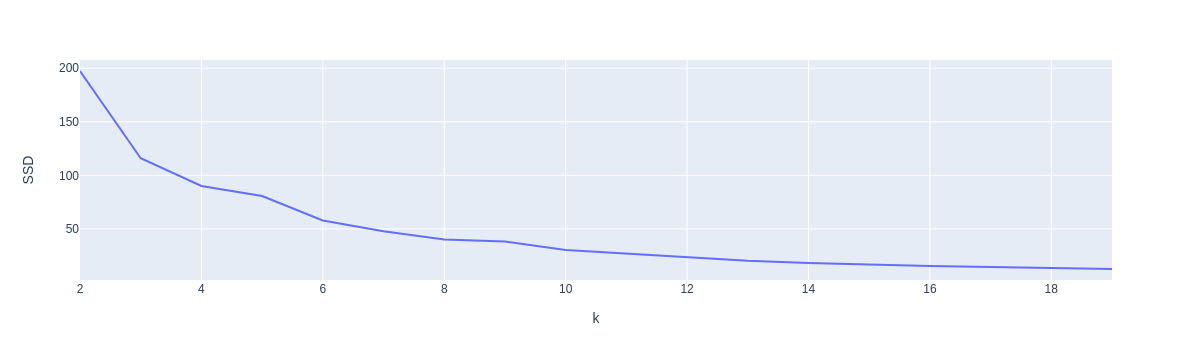

In [41]:
px.line(pd.DataFrame({"SSD": sse, "k":list_k}), x="k", y = "SSD")

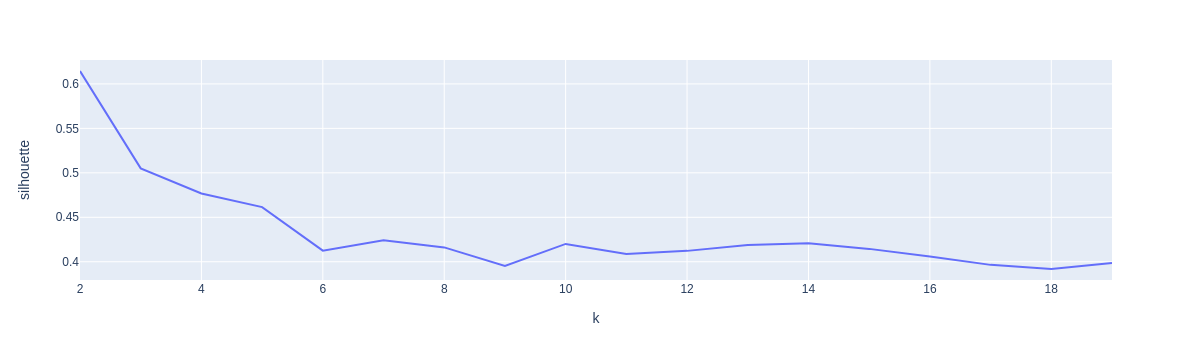

In [42]:
px.line(pd.DataFrame({"silhouette": silhouette, "k":list_k}), x="k", y = "silhouette")

## DBSCAN

## 🧠 THÉORIE — DBSCAN : le clustering par DENSITÉ

Une approche radicalement différente de KMeans :
- **Pas besoin de choisir k** ! DBSCAN trouve tout seul le nombre de clusters.
- Il regroupe les points **densément entassés**, et marque les points isolés comme **bruit** (label **−1**).
- Il gère les formes **arbitraires** (allongées, entrelacées) là où KMeans échoue.

**Deux paramètres :**
- **`eps`** : le rayon de voisinage — deux points à moins de `eps` sont « voisins ».
- **`min_samples`** : le nombre minimum de voisins pour former un cœur de cluster.

`fit_predict` renvoie les labels ; `np.unique(labels)` montre les clusters trouvés (dont le `-1` = bruit).

**⚠️ DBSCAN est très sensible à `eps`** : trop petit → tout devient du bruit / plein de mini-clusters ; trop grand → tout fusionne en un seul bloc. Le bon réglage se cherche (souvent après standardisation).

Ici `eps=0.9` sur les données standardisées+PCA.

In [43]:
from sklearn.cluster import DBSCAN

In [57]:
dbscan = DBSCAN(eps=0.9, min_samples=5)
cluster_DB = dbscan.fit_predict(X_pca)

In [55]:
np.unique(cluster_DB)

array([-1,  0,  1])

🔍 Le résultat DBSCAN : sur Iris, setosa (bien séparée) forme un cluster net, tandis que versicolor et virginica (qui se touchent) risquent de fusionner ou de générer du bruit selon `eps`.

## 📝 Résumé
KMeans (k imposé) vs DBSCAN (k automatique + détection du bruit) sur les mêmes données. Deux philosophies : centres vs densité.

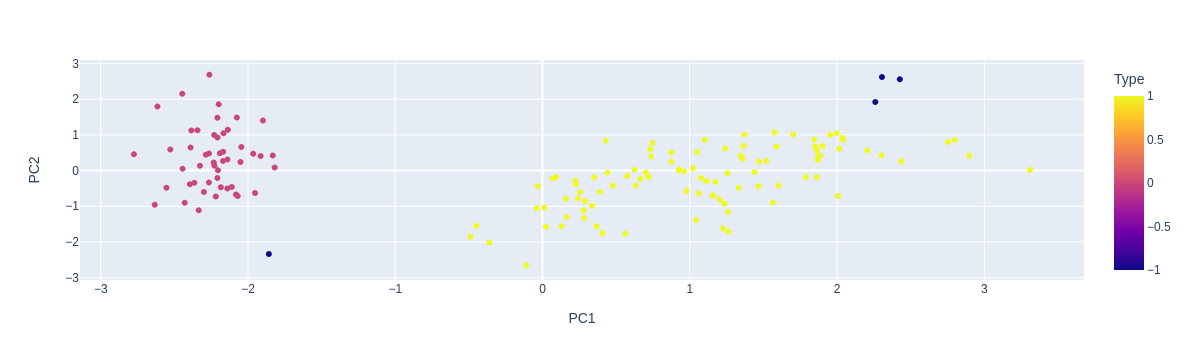

In [56]:
df_plot = pd.DataFrame({"PC1": X_pca[:,0], "PC2":X_pca[:,1], "Type": cluster_DB})
px.scatter(df_plot, x = "PC1", y= "PC2", color="Type")